# Contextual RAG

Contextual RAG añade una pregunta: **¿en qué circunstancias se genera ese ataque?**

Ser local, viajar, jugar a otra altura, ir ganando, sufrir una expulsión o entrar al tramo final puede cambiar el peligro que produce un equipo. 

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 12, "axes.titleweight": "bold",
})

def finish_chart(fig, subtitle, subtitle_y=0.90):
    fig.text(0.06, subtitle_y, subtitle, fontsize=10.5, color=MUTED, ha="left")

def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((candidate for candidate in data_candidates if candidate.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

context = pd.read_csv(DATA_DIR / "contextual_rag.csv", encoding="utf-8-sig")
segments = pd.read_csv(DATA_DIR / "clasico_contextual_segments.csv", encoding="utf-8-sig")
context["date"] = pd.to_datetime(context["date"])

required_columns = {
    "match_id", "date", "league_id", "league_name", "home_team", "away_team",
    "home_elevation_dif", "away_elevation_dif", "away_travel",
    "teamA_fr_rag", "teamB_fr_rag", "minutes_played", "time_segment",
    "match_state", "player_dif", "teamA_xg", "teamB_xg",
    "source_segments", "first_segment_id", "last_segment_id",
}
segment_columns = {
    "segment_id", "match_id", "minutes_played", "time_segment", "match_state",
    "player_dif", "minutes_strength", "teamA_fr_rag", "teamB_fr_rag",
    "teamA_xg", "teamB_xg",
}
key_columns = ["match_id", "time_segment", "match_state", "player_dif"]
assert required_columns.issubset(context.columns)
assert segment_columns.issubset(segments.columns)
assert not context.duplicated(key_columns).any()
assert context[list(required_columns)].notna().all().all()
assert segments[list(segment_columns)].notna().all().all()
assert (context["minutes_played"] > 0).all() and (segments["minutes_played"] > 0).all()

booster = xgb.Booster()
booster.load_model(DATA_DIR / "crag_booster.json")
EXPECTED_FEATURES = [
    "elevation_dif", "travel", "is_home",
    "match_state_-0.5", "match_state_-1.5", "match_state_0.0",
    "match_state_0.5", "match_state_1.5",
    "player_dif_-0.5", "player_dif_-1.5", "player_dif_0.0",
    "player_dif_0.5", "player_dif_1.5",
    "time_segment_1", "time_segment_2", "time_segment_3",
    "time_segment_4", "time_segment_5", "time_segment_6",
]
assert booster.feature_names == EXPECTED_FEATURES



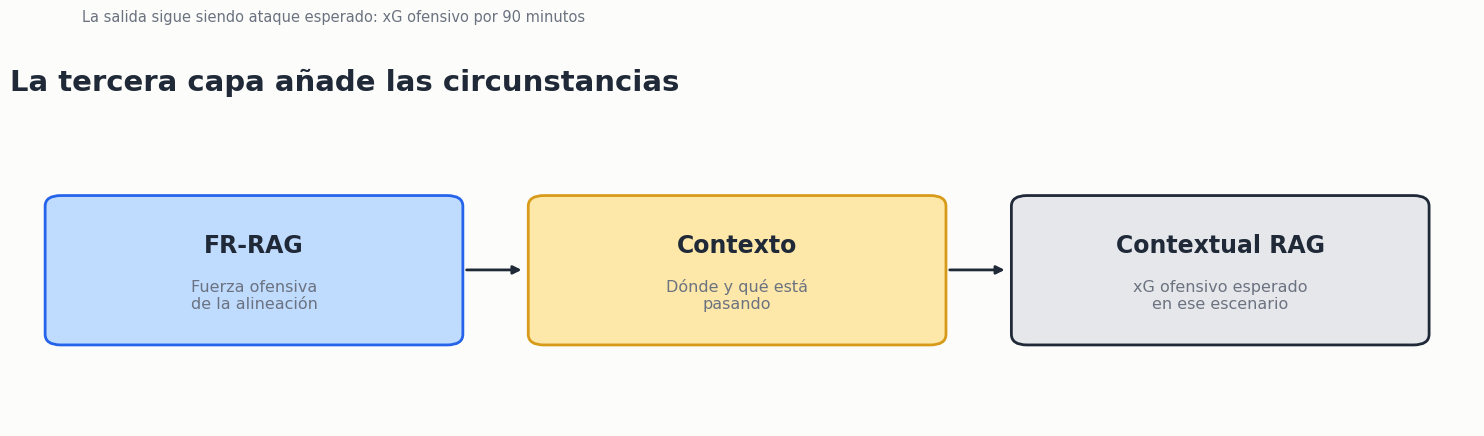

In [3]:
fig, ax = plt.subplots(figsize=(15, 4.8))
ax.set_xlim(0, 15)
ax.set_ylim(0, 4.8)
ax.axis("off")

boxes = [
    (0.4, "FR-RAG", "Fuerza ofensiva\nde la alineación", BLUE_LIGHT, BLUE),
    (5.35, "Contexto", "Dónde y qué está\npasando", GOLD_LIGHT, GOLD),
    (10.3, "Contextual RAG", "xG ofensivo esperado\nen ese escenario", "#E5E7EB", INK),
]
for x, title, subtitle, fill, edge in boxes:
    patch = FancyBboxPatch((x, 1.25), 4.2, 2.15, boxstyle="round,pad=0.04,rounding_size=0.16",
                           facecolor=fill, edgecolor=edge, linewidth=2)
    ax.add_patch(patch)
    ax.text(x + 2.1, 2.7, title, ha="center", va="center", fontsize=17, fontweight="bold", color=INK)
    ax.text(x + 2.1, 1.95, subtitle, ha="center", va="center", fontsize=11.5, color=MUTED)
for start in (4.65, 9.6):
    ax.annotate("", xy=(start + 0.62, 2.33), xytext=(start, 2.33),
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=2))
ax.set_title("La tercera capa añade las circunstancias", loc="left", fontsize=21, pad=10)
finish_chart(fig, "La salida sigue siendo ataque esperado: xG ofensivo por 90 minutos", subtitle_y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

## Dos tipos de contexto

El modelo combina señales conocidas antes del partido con otras que cambian mientras rueda el balón.

- **Contexto previo:** localía, diferencia de altura y distancia de viaje.
- **Contexto dinámico:** estado del marcador, diferencia de jugadores y bloque de 15 minutos.

In [4]:
coverage = pd.Series({
    "Contextos agrupados": f"{len(context):,}",
    "Segmentos originales": f"{int(context['source_segments'].sum()):,}",
    "Partidos": f"{context['match_id'].nunique():,}",
    "Ligas": f"{context['league_id'].nunique():,}",
    "Fecha inicial": context["date"].min().date().isoformat(),
    "Fecha final": context["date"].max().date().isoformat(),
})
display(coverage.to_frame("Cobertura"))

,Cobertura
Contextos agrupados,"33,311"
Segmentos originales,"58,003"
Partidos,"4,065"
Ligas,8
Fecha inicial,2024-01-01
Fecha final,2025-07-25


## Cómo funciona XGBoost

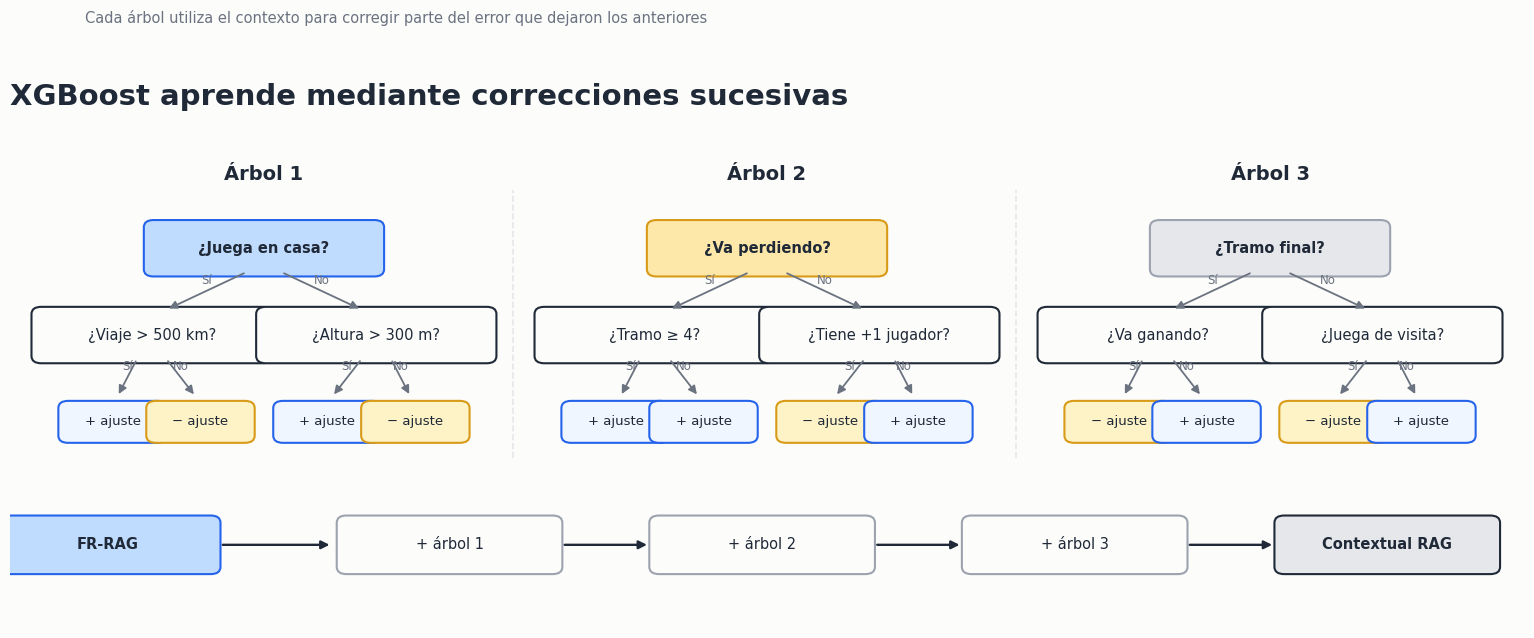

In [5]:
fig, ax = plt.subplots(figsize=(15.5, 7.0))
ax.set_xlim(0, 15.5)
ax.set_ylim(0, 7)
ax.axis("off")


def tree_box(x, y, text, width=2.4, height=0.72,
             fill=PAPER, edge=INK, fontsize=10.5, bold=False):
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width, height,
        boxstyle="round,pad=0.03,rounding_size=0.10",
        facecolor=fill,
        edgecolor=edge,
        linewidth=1.5,
    )
    ax.add_patch(patch)
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        color=INK,
    )


def branch(x1, y1, x2, y2, label):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.3),
    )
    ax.text(
        (x1 + x2) / 2,
        (y1 + y2) / 2 + 0.10,
        label,
        fontsize=8.5,
        color=MUTED,
        ha="center",
    )


# Tamaño más pequeño para los rectángulos de ajuste
AJ_W = 1.05
AJ_H = 0.52

tree_centers = [2.6, 7.75, 12.9]
titles = [
    "Árbol 1",
    "Árbol 2",
    "Árbol 3",
]

for x, title in zip(tree_centers, titles):
    ax.text(
        x, 6.20, title,
        ha="center",
        fontsize=14,
        fontweight="bold",
        color=INK,
    )


# ── Árbol 1 ────────────────────────────────────────────────────────────────
x = tree_centers[0]

tree_box(x, 5.25, "¿Juega en casa?", fill=BLUE_LIGHT, edge=BLUE, bold=True)

tree_box(x - 1.15, 4.05, "¿Viaje > 500 km?")
tree_box(x + 1.15, 4.05, "¿Altura > 300 m?")

branch(x - 0.18, 4.92, x - 1.00, 4.40, "Sí")
branch(x + 0.18, 4.92, x + 1.00, 4.40, "No")

tree_box(x - 1.55, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)
tree_box(x - 0.65, 2.85, "− ajuste", width=AJ_W, height=AJ_H,
         fill="#FEF3C7", edge=GOLD, fontsize=9.5)
tree_box(x + 0.65, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)
tree_box(x + 1.55, 2.85, "− ajuste", width=AJ_W, height=AJ_H,
         fill="#FEF3C7", edge=GOLD, fontsize=9.5)

branch(x - 1.30, 3.72, x - 1.50, 3.20, "Sí")
branch(x - 1.00, 3.72, x - 0.70, 3.20, "No")
branch(x + 1.00, 3.72, x + 0.70, 3.20, "Sí")
branch(x + 1.30, 3.72, x + 1.50, 3.20, "No")


# ── Árbol 2 ────────────────────────────────────────────────────────────────
x = tree_centers[1]

tree_box(x, 5.25, "¿Va perdiendo?", fill=GOLD_LIGHT, edge=GOLD, bold=True)

tree_box(x - 1.15, 4.05, "¿Tramo ≥ 4?")
tree_box(x + 1.15, 4.05, "¿Tiene +1 jugador?")

branch(x - 0.18, 4.92, x - 1.00, 4.40, "Sí")
branch(x + 0.18, 4.92, x + 1.00, 4.40, "No")

tree_box(x - 1.55, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)
tree_box(x - 0.65, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)
tree_box(x + 0.65, 2.85, "− ajuste", width=AJ_W, height=AJ_H,
         fill="#FEF3C7", edge=GOLD, fontsize=9.5)
tree_box(x + 1.55, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)

branch(x - 1.30, 3.72, x - 1.50, 3.20, "Sí")
branch(x - 1.00, 3.72, x - 0.70, 3.20, "No")
branch(x + 1.00, 3.72, x + 0.70, 3.20, "Sí")
branch(x + 1.30, 3.72, x + 1.50, 3.20, "No")


# ── Árbol 3 ────────────────────────────────────────────────────────────────
x = tree_centers[2]

tree_box(x, 5.25, "¿Tramo final?", fill="#E5E7EB", edge=GREY, bold=True)

tree_box(x - 1.15, 4.05, "¿Va ganando?")
tree_box(x + 1.15, 4.05, "¿Juega de visita?")

branch(x - 0.18, 4.92, x - 1.00, 4.40, "Sí")
branch(x + 0.18, 4.92, x + 1.00, 4.40, "No")

tree_box(x - 1.55, 2.85, "− ajuste", width=AJ_W, height=AJ_H,
         fill="#FEF3C7", edge=GOLD, fontsize=9.5)
tree_box(x - 0.65, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)
tree_box(x + 0.65, 2.85, "− ajuste", width=AJ_W, height=AJ_H,
         fill="#FEF3C7", edge=GOLD, fontsize=9.5)
tree_box(x + 1.55, 2.85, "+ ajuste", width=AJ_W, height=AJ_H,
         fill="#EFF6FF", edge=BLUE, fontsize=9.5)

branch(x - 1.30, 3.72, x - 1.50, 3.20, "Sí")
branch(x - 1.00, 3.72, x - 0.70, 3.20, "No")
branch(x + 1.00, 3.72, x + 0.70, 3.20, "Sí")
branch(x + 1.30, 3.72, x + 1.50, 3.20, "No")


# Separadores entre árboles
for xpos in [5.15, 10.3]:
    ax.plot(
        [xpos, xpos], [2.35, 6.05],
        color=GRID, linewidth=1.2, linestyle="--"
    )


# Flujo conceptual inferior
steps = [
    (1.0, "FR-RAG", BLUE_LIGHT, BLUE),
    (4.5, "+ árbol 1", PAPER, GREY),
    (7.7, "+ árbol 2", PAPER, GREY),
    (10.9, "+ árbol 3", PAPER, GREY),
    (14.1, "Contextual RAG", "#E5E7EB", INK),
]

for x, label, fill, edge in steps:
    tree_box(
        x, 1.15, label,
        width=2.25,
        height=0.75,
        fill=fill,
        edge=edge,
        bold=label in ["FR-RAG", "Contextual RAG"],
    )

for x1, x2 in [(2.15, 3.30), (5.65, 6.55), (8.85, 9.75), (12.05, 12.95)]:
    ax.annotate(
        "",
        xy=(x2, 1.15),
        xytext=(x1, 1.15),
        arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.7),
    )


ax.set_title(
    "XGBoost aprende mediante correcciones sucesivas",
    loc="left",
    fontsize=21,
    pad=12,
)

finish_chart(
    fig,
    "Cada árbol utiliza el contexto para corregir parte del error que dejaron los anteriores",
    subtitle_y=0.89,
)

plt.tight_layout(rect=(0, 0, 1, 0.83))
plt.show()

## Predicción contextual

In [6]:
def category_text(value):
    value = float(value)
    return "0.0" if value == 0 else str(value)

def encode_features(frame):
    encoded = frame.copy()
    for column in ["match_state", "player_dif"]:
        encoded[column] = encoded[column].map(category_text)
    encoded["time_segment"] = encoded["time_segment"].astype(int).astype(str)
    encoded["is_home"] = encoded["is_home"].astype(int)
    categorical = pd.get_dummies(encoded[["match_state", "player_dif", "time_segment"]],
                                 prefix=["match_state", "player_dif", "time_segment"])
    matrix = pd.concat([
        encoded[["elevation_dif", "travel", "is_home"]].reset_index(drop=True),
        categorical.reset_index(drop=True),
    ], axis=1)
    return matrix.reindex(columns=EXPECTED_FEATURES, fill_value=0).astype(float)

def predict_context(frame):
    matrix = encode_features(frame)
    baseline = frame["fr_rag90"].astype(float).clip(lower=0.01).to_numpy()
    prediction = booster.predict(xgb.DMatrix(matrix, base_margin=np.log(baseline)))
    assert np.isfinite(prediction).all() and (prediction > 0).all()
    return prediction

def team_perspective(frame, side):
    home = side == "home"
    result = pd.DataFrame({
        "match_id": frame["match_id"],
        "team": frame["home_team"] if home else frame["away_team"],
        "minutes_played": frame["minutes_played"],
        "source_segments": frame["source_segments"],
        "first_segment_id": frame["first_segment_id"],
        "time_segment": frame["time_segment"].astype(int),
        "is_home": int(home),
        "elevation_dif": frame["home_elevation_dif"] if home else frame["away_elevation_dif"],
        "travel": -frame["away_travel"] if home else frame["away_travel"],
        "match_state": frame["match_state"] if home else -frame["match_state"],
        "player_dif": frame["player_dif"] if home else -frame["player_dif"],
        "fr_rag": frame["teamA_fr_rag"] if home else frame["teamB_fr_rag"],
        "actual_xg": frame["teamA_xg"] if home else frame["teamB_xg"],
    })
    result["fr_rag90"] = result["fr_rag"] / result["minutes_played"] * 90
    result["actual_xg90"] = result["actual_xg"] / result["minutes_played"] * 90
    result["match_state"] = result["match_state"].mask(result["match_state"] == 0, 0.0)
    result["player_dif"] = result["player_dif"].mask(result["player_dif"] == 0, 0.0)
    result["contextual_rag90"] = predict_context(result)
    result["multiplier"] = result["contextual_rag90"] / result["fr_rag90"]
    return result

In [7]:
SHAP_GROUPS = {
    "Altura": ["elevation_dif"],
    "Viaje": ["travel"],
    "Localía": ["is_home"],
    "Marcador": [name for name in EXPECTED_FEATURES if name.startswith("match_state_")],
    "Jugadores": [name for name in EXPECTED_FEATURES if name.startswith("player_dif_")],
    "Tiempo": [name for name in EXPECTED_FEATURES if name.startswith("time_segment_")],
}

all_teams = pd.concat([
    team_perspective(context, "home"),
    team_perspective(context, "away"),
], ignore_index=True)
contextual_xg90 = np.average(all_teams["contextual_rag90"], weights=all_teams["minutes_played"])

def shap_contributions(frame):
    matrix = encode_features(frame)
    baseline = np.log(frame["fr_rag90"].astype(float).clip(lower=0.01).to_numpy())
    dmatrix = xgb.DMatrix(matrix, base_margin=baseline)
    contributions = booster.predict(dmatrix, pred_contribs=True)
    margins = booster.predict(dmatrix, output_margin=True)
    predictions = booster.predict(dmatrix)
    assert np.allclose(contributions.sum(axis=1), margins, atol=1e-5)
    assert np.allclose(np.exp(margins), predictions, rtol=1e-5, atol=1e-5)
    feature_shap = pd.DataFrame(contributions[:, :-1], columns=EXPECTED_FEATURES, index=frame.index)
    grouped = pd.DataFrame({
        group: feature_shap[columns].sum(axis=1)
        for group, columns in SHAP_GROUPS.items()
    }, index=frame.index)
    return grouped, contributions[:, -1], predictions

def render_manual_scenario(fr_rag90, es_local, altura_relativa_m,
                           distancia_partido_km, estado_marcador,
                           diferencia_jugadores, tramo_partido):
    scenario = pd.DataFrame([{
        "fr_rag90": fr_rag90,
        "is_home": int(es_local),
        "elevation_dif": altura_relativa_m,
        "travel": -distancia_partido_km if es_local else distancia_partido_km,
        "match_state": estado_marcador,
        "player_dif": diferencia_jugadores,
        "time_segment": tramo_partido,
    }])

    grouped, bias, prediction = shap_contributions(scenario)
    prediction = float(prediction[0])
    model_average = float(contextual_xg90)

    # FR-RAG and the booster intercept form one calibrated starting contribution.
    # The one-hot columns are then regrouped into the five reader-facing signals.
    calibrated_lineup_log = float(bias[0]) - np.log(model_average)
    context_order = ["Viaje", "Tiempo", "Marcador", "Jugadores", "Altura"]
    components = pd.concat([
        pd.Series({"Fuerza de alineación calibrada": calibrated_lineup_log}),
        grouped.iloc[0][context_order],
    ])

    cumulative = [model_average]
    for contribution in components:
        cumulative.append(cumulative[-1] * np.exp(contribution))
    cumulative[-1] = prediction
    starts = np.minimum(cumulative[:-1], cumulative[1:])
    widths = np.abs(np.diff(cumulative))
    deltas = np.diff(cumulative)

    condition = "Local" if es_local else "Visitante"
    display(Markdown(
        f"**Escenario elegido:** {condition} · tramo {tramo_partido} · marcador {estado_marcador:+.1f} · "
        f"jugadores {diferencia_jugadores:+.1f} · altura {altura_relativa_m:+.0f} m · "
        f"distancia {distancia_partido_km:.0f} km  \n"
        f"**Predicción contextual:** **{prediction:.3f} xG/90**."
    ))

    fig, ax = plt.subplots(figsize=(13.2, 7.6))
    y = np.arange(len(components))
    colors = [BLUE_LIGHT if delta >= 0 else GOLD_LIGHT for delta in deltas]
    bars = ax.barh(y, widths, left=starts, color=colors, edgecolor=INK, height=0.60)
    ax.set_yticks(y, components.index)
    ax.invert_yaxis()

    for position in range(len(components) - 1):
        ax.plot([cumulative[position + 1], cumulative[position + 1]],
                [position + 0.30, position + 0.70], color=GREY, linewidth=0.9)

    span = max(cumulative) - min(cumulative)
    label_offset = max(span * 0.018, 0.015)
    for position, (bar, delta) in enumerate(zip(bars, deltas)):
        if abs(delta) < 0.0005:
            ax.scatter(cumulative[position + 1], position, s=22, color=INK, zorder=3)
        ax.text(max(cumulative[position], cumulative[position + 1]) + label_offset,
                position, f"{delta:+.3f}", va="center", ha="left",
                fontsize=10.5, fontweight="bold", color=INK)

    start_value = model_average
    end_value = prediction
    ax.axvline(start_value, color=INK, linewidth=2, linestyle="--")
    ax.axvline(end_value, color=BLUE, linewidth=2.4)
    ax.text(start_value, -0.78, f"Promedio del modelo\n{start_value:.3f}",
            ha="center", va="bottom", fontsize=10.5, fontweight="bold", color=INK)
    ax.text(end_value, -0.78, f"Contextual RAG final\n{end_value:.3f}",
            ha="center", va="bottom", fontsize=10.5, fontweight="bold", color=BLUE)

    low = min(cumulative)
    high = max(cumulative)
    padding = max((high - low) * 0.20, 0.18)
    ax.set_xlim(max(0, low - padding), high + padding * 1.25)
    ax.set_xlabel("xG ofensivo por 90 minutos")
    ax.set_title("Recorrido de la predicción contextual", loc="left", pad=54, fontsize=20)
    clean_axes(ax, grid_axis="x")
    finish_chart(fig, "Cada barra muestra solamente cuánto sube o baja el xG/90", subtitle_y=0.91)
    plt.tight_layout(rect=(0, 0, 1, 0.84))
    plt.show()


**Escenario elegido:** Local · tramo 1 · marcador +0.0 · jugadores +0.0 · altura -86 m · distancia 501 km  
**Predicción contextual:** **1.977 xG/90**.

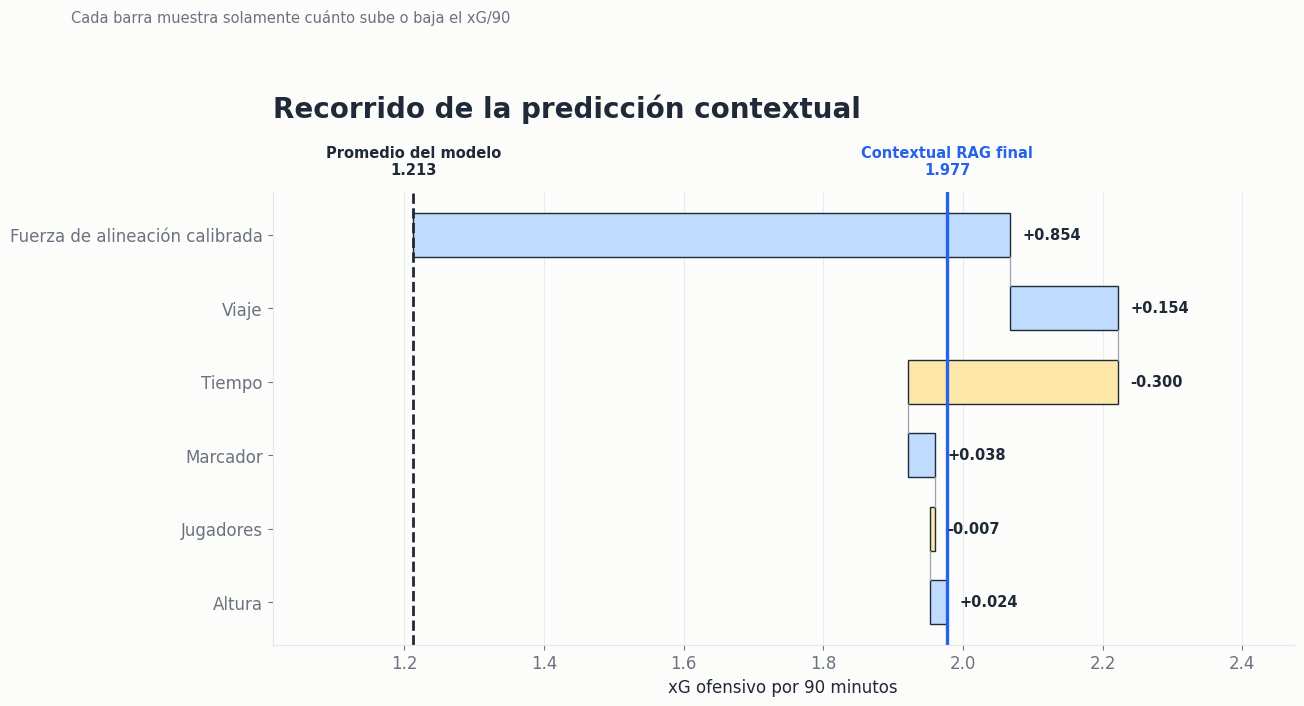

In [29]:
# EDITA ESTOS VALORES Y VUELVE A EJECUTAR ESTA MISMA CELDA
FR_RAG_90 = 3.14
ES_LOCAL = True
ALTURA_RELATIVA_M = -86 # -86 Barca y 219 Madrid
DISTANCIA_PARTIDO_KM = 501
ESTADO_MARCADOR = 0.0      # -1.5, -0.5, 0.0, 0.5, 1.5
DIFERENCIA_JUGADORES = 0.0  # -1.5, -0.5, 0.0, 0.5, 1.5
TRAMO_PARTIDO = 1         # 1=0–15 ... 6=76–90+

render_manual_scenario(
    FR_RAG_90, ES_LOCAL, ALTURA_RELATIVA_M, DISTANCIA_PARTIDO_KM,
    ESTADO_MARCADOR, DIFERENCIA_JUGADORES, TRAMO_PARTIDO,
)


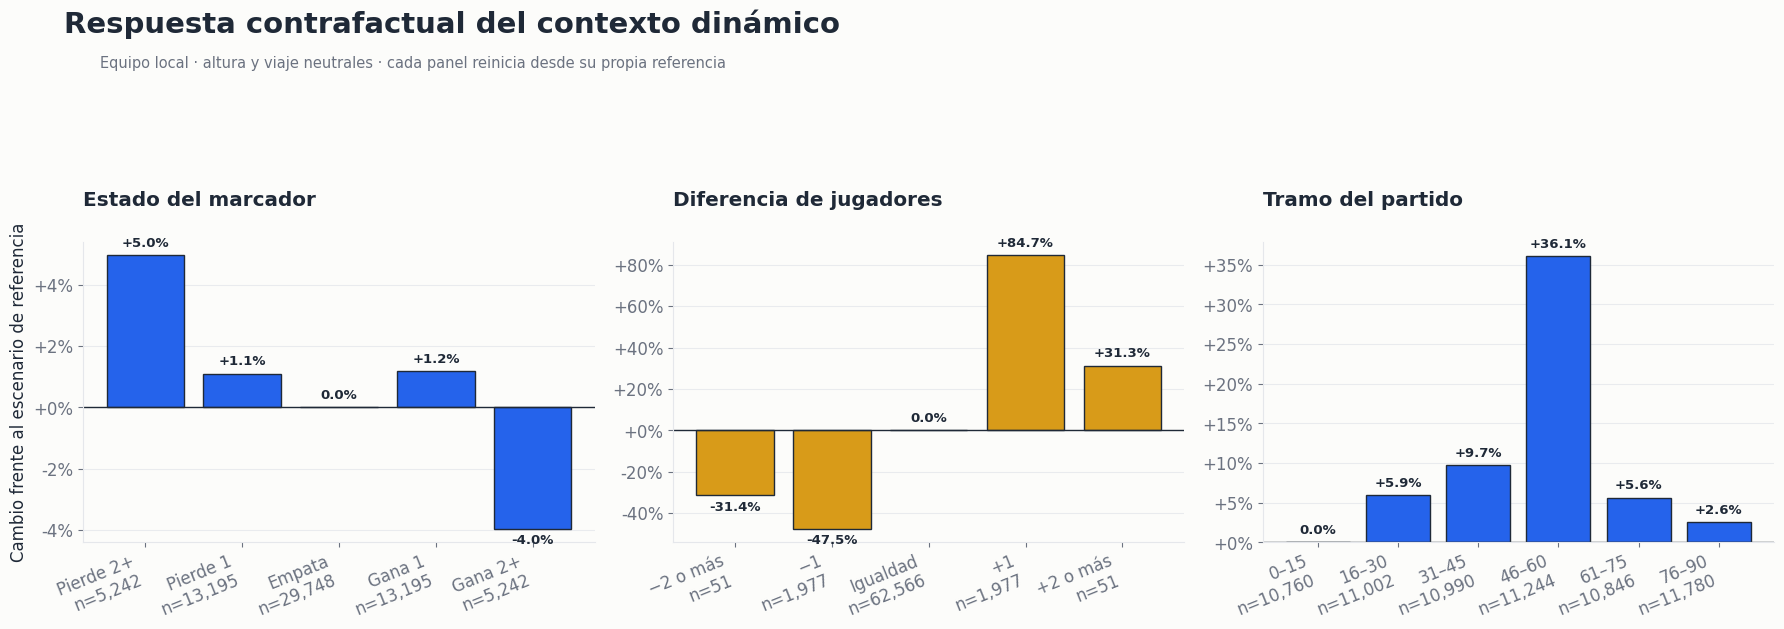

In [9]:
def scenarios(values, feature, **fixed):
    frame = pd.DataFrame({feature: values})
    defaults = {
        "fr_rag90": 1.0, "is_home": 1, "elevation_dif": 0, "travel": 0,
        "match_state": 0.0, "player_dif": 0.0, "time_segment": 1,
    }
    defaults.update(fixed)
    for column, value in defaults.items():
        if column not in frame:
            frame[column] = value
    frame["prediction"] = predict_context(frame)
    frame["total_adjustment"] = frame["prediction"] / frame["fr_rag90"]
    return frame

def relative_to(frame, reference_value):
    reference = frame.loc[reference_value, "total_adjustment"]
    frame["change_vs_reference"] = frame["total_adjustment"] / reference - 1
    return frame

def label_percent_bars(ax, bars, values):
    labels = [f"{value:+.1%}" if abs(value) >= 0.0005 else "0.0%" for value in values]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9.5, fontweight="bold")

states = [-1.5, -0.5, 0.0, 0.5, 1.5]
state_labels = ["Pierde 2+", "Pierde 1", "Empata", "Gana 1", "Gana 2+"]
player_labels = ["−2 o más", "−1", "Igualdad", "+1", "+2 o más"]

state_effect = relative_to(scenarios(states, "match_state").set_index("match_state"), 0.0)
player_effect = relative_to(scenarios(states, "player_dif").set_index("player_dif"), 0.0)
time_effect = relative_to(scenarios(range(1, 7), "time_segment").set_index("time_segment"), 1)

state_counts = all_teams["match_state"].value_counts()
player_counts = all_teams["player_dif"].value_counts()
time_counts = all_teams["time_segment"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6.4))
specs = [
    (state_effect, state_labels, [state_counts.get(value, 0) for value in states], "Estado del marcador", BLUE),
    (player_effect, player_labels, [player_counts.get(value, 0) for value in states], "Diferencia de jugadores", GOLD),
    (time_effect, ["0–15", "16–30", "31–45", "46–60", "61–75", "76–90"],
     [time_counts.get(value, 0) for value in range(1, 7)], "Tramo del partido", BLUE),
]

for ax, (frame, labels, counts, title, color) in zip(axes, specs):
    labels_with_n = [f"{label}\nn={count:,}" for label, count in zip(labels, counts)]
    bars = ax.bar(np.arange(len(frame)), frame["change_vs_reference"], color=color, edgecolor=INK)
    label_percent_bars(ax, bars, frame["change_vs_reference"])
    ax.set_xticks(np.arange(len(frame)), labels_with_n, rotation=22, ha="right")
    ax.axhline(0, color=INK, linewidth=1)
    ax.yaxis.set_major_formatter(lambda value, position: f"{value:+.0%}")
    ax.set_title(title, loc="left", pad=26)
    clean_axes(ax)

axes[0].set_ylabel("Cambio frente al escenario de referencia")
fig.suptitle("Respuesta contrafactual del contexto dinámico", x=0.04, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Equipo local · altura y viaje neutrales · cada panel reinicia desde su propia referencia", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.80))
plt.show()

## El Clásico con contexto

El caso final es Barcelona–Real Madrid del **11 de mayo de 2025**. Barcelona juega como local; su altura relativa es **−86 m**. Real Madrid aparece con **+219 m** y la distancia registrada entre ambos equipos es **501 km**.

El archivo de segmentos conserva las **19 situaciones originales y 98 minutos**. Cada segmento utiliza el marcador, la diferencia de jugadores y el tramo que estaban vigentes durante esos minutos.

In [10]:
CLASICO_ID = 28055
clasico_grouped = context[context["match_id"] == CLASICO_ID].sort_values("first_segment_id").copy()
clasico_segments = segments[segments["match_id"] == CLASICO_ID].sort_values("segment_id").copy()
meta = clasico_grouped.iloc[0]

assert len(clasico_segments) == 19
assert int(clasico_segments["minutes_played"].sum()) == 98
assert np.isclose(clasico_segments["teamA_xg"].sum(), 4.27)
assert np.isclose(clasico_segments["teamB_xg"].sum(), 2.74)
assert meta["home_team"] == "Barcelona" and meta["away_team"] == "Real Madrid"
assert meta["home_elevation_dif"] == -86 and meta["away_elevation_dif"] == 219
assert meta["away_travel"] == 501

clasico_segments["home_team"] = meta["home_team"]
clasico_segments["away_team"] = meta["away_team"]
clasico_segments["home_elevation_dif"] = meta["home_elevation_dif"]
clasico_segments["away_elevation_dif"] = meta["away_elevation_dif"]
clasico_segments["away_travel"] = meta["away_travel"]
clasico_segments["source_segments"] = 1
clasico_segments["first_segment_id"] = clasico_segments["segment_id"]

clasico_teams = pd.concat([
    team_perspective(clasico_segments, "home"),
    team_perspective(clasico_segments, "away"),
], ignore_index=True)
assert (clasico_teams.loc[clasico_teams["is_home"] == 1, "travel"] == -501).all()
assert (clasico_teams.loc[clasico_teams["is_home"] == 0, "travel"] == 501).all()

kickoff = clasico_teams.sort_values("first_segment_id").groupby("team", sort=False).first()
display(pd.DataFrame({
    "Condición": ["Local", "Visitante"],
    "Altura relativa": ["−86 m", "+219 m"],
    "Distancia modelada": ["−501 km", "+501 km"],
    "Marcador": ["Empate", "Empate"],
    "Jugadores": ["11 vs 11", "11 vs 11"],
}, index=["Barcelona", "Real Madrid"]))

,Condición,Altura relativa,Distancia modelada,Marcador,Jugadores
Barcelona,Local,−86 m,−501 km,Empate,11 vs 11
Real Madrid,Visitante,+219 m,+501 km,Empate,11 vs 11


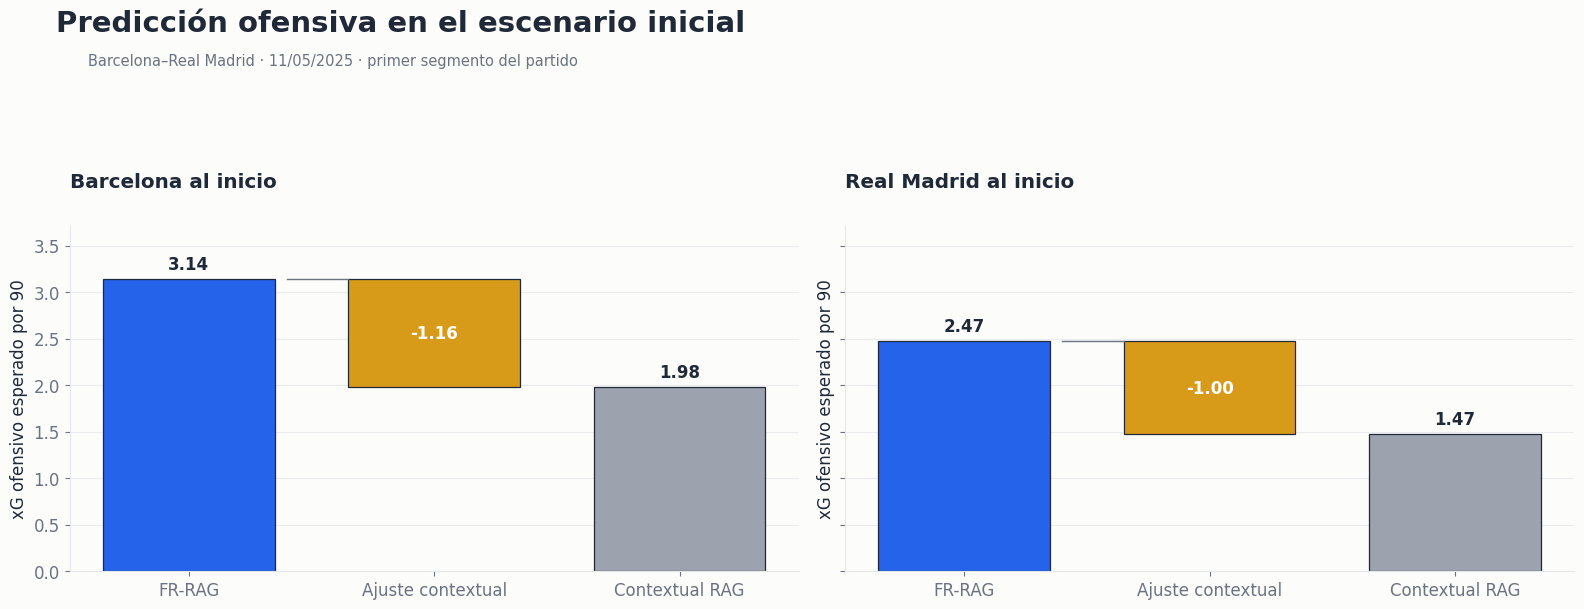

In [11]:
def draw_context_waterfall(ax, baseline, prediction, title):
    adjustment = prediction - baseline
    starts = [0, baseline, 0]
    values = [baseline, adjustment, prediction]
    colors = [BLUE, GOLD if adjustment < 0 else BLUE_LIGHT, GREY]
    labels = ["FR-RAG", "Ajuste contextual", "Contextual RAG"]
    for index, (start, value, color) in enumerate(zip(starts, values, colors)):
        bottom = start if value >= 0 else start + value
        ax.bar(index, abs(value), bottom=bottom, color=color, edgecolor=INK, linewidth=0.9, width=0.7)
        if index == 1:
            ax.text(index, start + value / 2, f"{value:+.2f}", ha="center", va="center",
                    color="white", fontweight="bold", fontsize=12)
        else:
            ax.text(index, value + 0.06, f"{value:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=12)
    ax.plot([0.4, 0.65], [baseline, baseline], color=MUTED, linewidth=1)
    ax.set_xticks(range(3), labels)
    ax.set_title(title, loc="left", pad=28)
    ax.set_ylabel("xG ofensivo esperado por 90")
    clean_axes(ax)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), sharey=True)
for ax, team in zip(axes, ["Barcelona", "Real Madrid"]):
    row = kickoff.loc[team]
    draw_context_waterfall(ax, row["fr_rag90"], row["contextual_rag90"], f"{team} al inicio")
upper = max(kickoff["fr_rag90"].max(), kickoff["contextual_rag90"].max()) * 1.18
for ax in axes:
    ax.set_ylim(0, upper)
fig.suptitle("Predicción ofensiva en el escenario inicial", x=0.04, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Barcelona–Real Madrid · 11/05/2025 · primer segmento del partido", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

### Contextual RAG acumulado durante el partido

La predicción por 90 se convierte en xG para la duración exacta de cada segmento. Después se acumula desde el minuto 0 hasta el 98. Cuando cambia el marcador, el siguiente segmento utiliza inmediatamente el nuevo estado del partido.

La gráfica muestra únicamente Contextual RAG: cada punto corresponde al cierre de uno de los 19 segmentos originales.

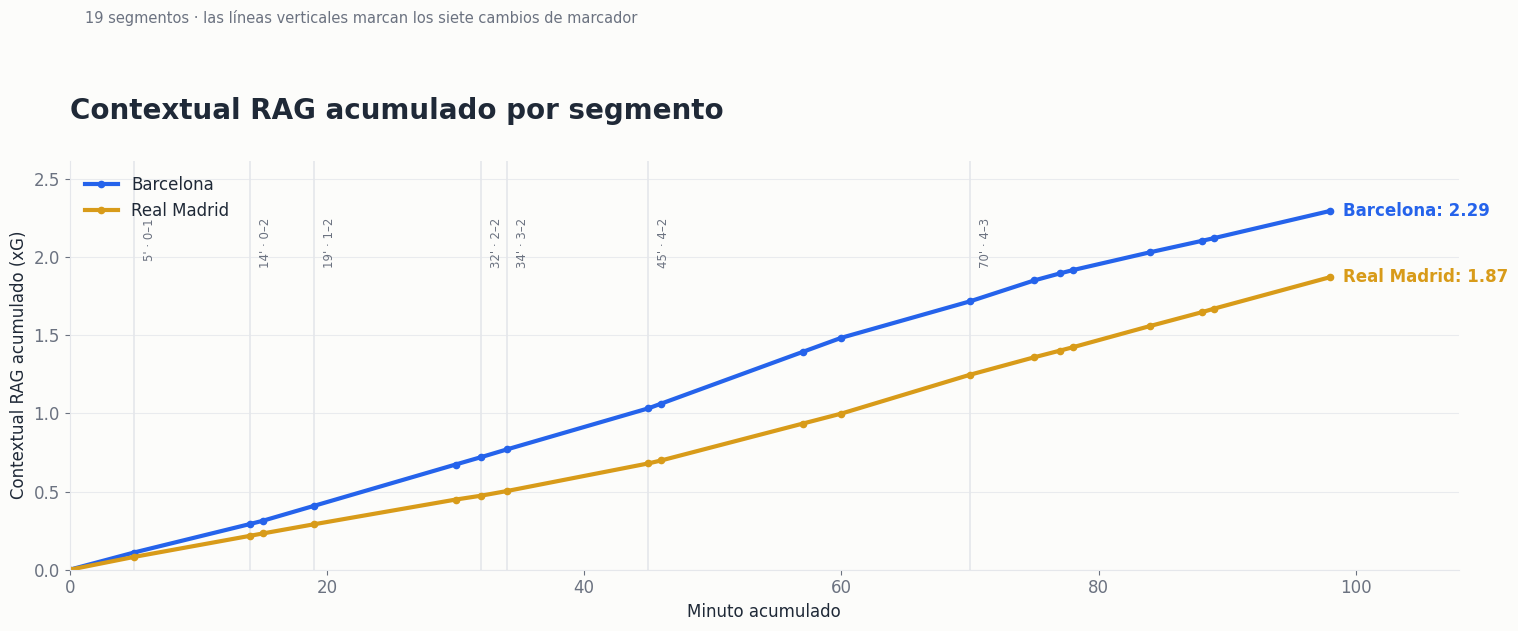

**Resultado acumulado:** Barcelona, **2.29 Contextual RAG** frente a **4.27 xG observado**; Real Madrid, **1.87 Contextual RAG** frente a **2.74 xG observado**.

In [12]:
timeline = {}
for team in ["Barcelona", "Real Madrid"]:
    rows = clasico_teams[clasico_teams["team"] == team].sort_values("first_segment_id").copy()
    rows["minute_end"] = rows["minutes_played"].cumsum()
    rows["segment_contextual_xg"] = rows["contextual_rag90"] * rows["minutes_played"] / 90
    rows["cumulative_contextual_xg"] = rows["segment_contextual_xg"].cumsum()
    timeline[team] = rows

home_segments = clasico_segments.copy()
home_segments["minute_end"] = home_segments["minutes_played"].cumsum()
home_segments["minute_start"] = home_segments["minute_end"] - home_segments["minutes_played"]
state_changes = home_segments[
    home_segments["match_state"].ne(home_segments["match_state"].shift(fill_value=0))
].copy()

home_score = away_score = 0
previous_state = 0.0
goal_events = []
for _, event in state_changes.iterrows():
    if event["match_state"] > previous_state:
        home_score += 1
    else:
        away_score += 1
    goal_events.append((int(event["minute_start"]), f"{home_score}–{away_score}"))
    previous_state = event["match_state"]
assert (home_score, away_score) == (4, 3)

fig, ax = plt.subplots(figsize=(15.5, 7.0))
for team, color in [("Barcelona", BLUE), ("Real Madrid", GOLD)]:
    rows = timeline[team]
    x = np.r_[0, rows["minute_end"].to_numpy()]
    y = np.r_[0, rows["cumulative_contextual_xg"].to_numpy()]
    ax.plot(x, y, color=color, linewidth=3, marker="o", markersize=4.5, label=team)

top = max(rows["cumulative_contextual_xg"].max() for rows in timeline.values())
for minute, score in goal_events:
    ax.axvline(minute, color=GRID, linewidth=1.2, zorder=0)
    ax.text(minute + 0.7, top * 0.98, f"{minute}' · {score}", rotation=90,
            va="top", ha="left", fontsize=8.5, color=MUTED)

for team, color in [("Barcelona", BLUE), ("Real Madrid", GOLD)]:
    rows = timeline[team]
    ax.text(rows["minute_end"].iloc[-1] + 1, rows["cumulative_contextual_xg"].iloc[-1],
            f"{team}: {rows['cumulative_contextual_xg'].iloc[-1]:.2f}",
            color=color, va="center", fontweight="bold")

ax.set_xlim(0, 108)
ax.set_ylim(0, top * 1.14)
ax.set_xlabel("Minuto acumulado")
ax.set_ylabel("Contextual RAG acumulado (xG)")
ax.set_title("Contextual RAG acumulado por segmento", loc="left", pad=30, fontsize=20)
ax.legend(frameon=False, loc="upper left")
clean_axes(ax)
finish_chart(fig, "19 segmentos · las líneas verticales marcan los siete cambios de marcador", subtitle_y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.80))
plt.show()

barcelona_contextual = timeline["Barcelona"]["segment_contextual_xg"].sum()
madrid_contextual = timeline["Real Madrid"]["segment_contextual_xg"].sum()
barcelona_observed = clasico_segments["teamA_xg"].sum()
madrid_observed = clasico_segments["teamB_xg"].sum()

display(Markdown(
    f"**Resultado acumulado:** Barcelona, **{barcelona_contextual:.2f} Contextual RAG** frente a "
    f"**{barcelona_observed:.2f} xG observado**; Real Madrid, **{madrid_contextual:.2f} Contextual RAG** "
    f"frente a **{madrid_observed:.2f} xG observado**."
))


## Qué nos llevamos

- Contextual RAG predice **xG ofensivo** para un equipo dentro de un escenario completo.
- FR-RAG aporta la fuerza de la alineación; el contexto incorpora localía, altura, viaje, marcador, jugadores y tiempo.
- El comparador manual muestra, en xG/90, cómo la alineación calibrada y las señales agrupadas del partido conducen a una única predicción contextual.
- En el Clásico, el Contextual RAG se recalcula en cada uno de los 19 segmentos y se acumula según los minutos realmente jugados.

## Checks de reproducibilidad

- Datos generales: `02_data/contextual_rag.csv`.
- Segmentos originales del Clásico: `02_data/clasico_contextual_segments.csv`.
- Modelo: `02_data/crag_booster.json`, cargado sin reentrenamiento ni modificaciones.
- SHAP: contribuciones nativas de XGBoost, traducidas a un recorrido acumulado en xG/90 para el ejemplo individual.
- Variables del booster: 19 columnas verificadas en nombre y orden.
- Caso final: `match_id=28055`, 19 segmentos, 98 minutos y xG observado de **4.27–2.74**.
- El notebook no abre conexiones SQL, no contiene credenciales y no necesita la base VSP para ejecutarse.